# US Superstore — Data Analysis & Visualization

This notebook loads, preprocesses, analyzes, and visualizes the US Superstore dataset. It answers the project questions on states, customers, cities, profitability, and the Pareto principle.

**Required packages:** `pandas`, `matplotlib`, `seaborn`, `xlrd`, `openpyxl`.

In [1]:
# If needed, run this once in your PyCharm terminal:
# pip install pandas matplotlib seaborn xlrd openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [2]:
# Keep the Excel file in the same folder as this notebook.
file_path = 'US_Superstore_data.xls'
df = pd.read_excel(file_path)

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## 1. Preprocessing

In [7]:
df.info()
print('\nMissing values:')
display(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


Duplicate rows: 0


In [9]:
# Convert date columns to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Remove rows missing fields needed for the analysis
df = df.dropna(subset=['Sales', 'Profit', 'State', 'Customer ID', 'Customer Name', 'City'])

# Check numeric columns
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
print(df[numeric_cols].describe())
print('\nCleaned shape:', df.shape)

          Sales  Quantity  Discount    Profit
count  9,994.00  9,994.00  9,994.00  9,994.00
mean     229.86      3.79      0.16     28.66
std      623.25      2.23      0.21    234.26
min        0.44      1.00      0.00 -6,599.98
25%       17.28      2.00      0.00      1.73
50%       54.49      3.00      0.20      8.67
75%      209.94      5.00      0.20     29.36
max   22,638.48     14.00      0.80  8,399.98

Cleaned shape: (9994, 21)


## 2. Which states have the most sales?

,Sales,Profit
State,,
California,"457,687.63","76,381.39"
New York,"310,876.27","74,038.55"
Texas,"170,188.05","-25,729.36"
Washington,"138,641.27","33,402.65"
Pennsylvania,"116,511.91","-15,559.96"
Florida,"89,473.71","-3,399.30"
Illinois,"80,166.10","-12,607.89"
Ohio,"78,258.14","-16,971.38"
Michigan,"76,269.61","24,463.19"


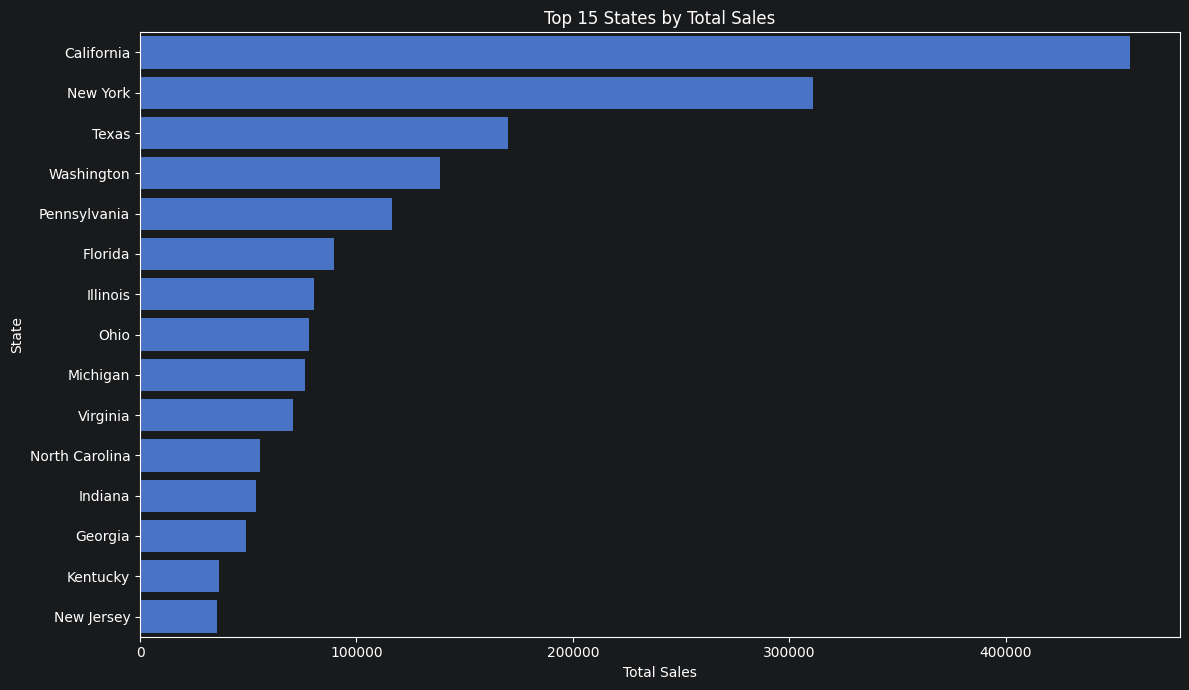

In [10]:
state_summary = (df.groupby('State')
                 .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
                 .sort_values('Sales', ascending=False))
display(state_summary.head(10))

plt.figure(figsize=(12,7))
sns.barplot(data=state_summary.head(15).reset_index(), y='State', x='Sales')
plt.title('Top 15 States by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## 3. New York vs California — Sales and Profit

In [ ]:
ny_ca = (df[df['State'].isin(['New York','California'])]
         .groupby('State')[['Sales','Profit']].sum())
display(ny_ca)

sales_difference = ny_ca.loc['California','Sales'] - ny_ca.loc['New York','Sales']
profit_difference = ny_ca.loc['California','Profit'] - ny_ca.loc['New York','Profit']
print(f'California sales exceed New York by: ${sales_difference:,.2f}')
print(f'California profit compared with New York: ${profit_difference:,.2f}')

ny_ca.plot(kind='bar', figsize=(9,6))
plt.title('California vs New York: Sales and Profit')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Outstanding customer in New York

Here, an outstanding customer is defined as the New York customer with the highest total sales. We also inspect profit so that high sales are not confused with high profitability.

In [ ]:
ny_customers = (df[df['State']=='New York']
                .groupby(['Customer ID','Customer Name'])
                .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
                .sort_values('Sales', ascending=False))
display(ny_customers.head(10))
print('Outstanding NY customer by sales:')
display(ny_customers.head(1))

## 5. Differences among states in profitability

In [ ]:
state_profitability = (df.groupby('State')
                        .agg(Sales=('Sales','sum'), Profit=('Profit','sum')))
state_profitability['Profit Margin'] = state_profitability['Profit'] / state_profitability['Sales']
state_profitability = state_profitability.sort_values('Profit', ascending=False)

print('Most profitable states:')
display(state_profitability.head(10))
print('States with negative total profit:')
display(state_profitability[state_profitability['Profit'] < 0].sort_values('Profit'))

plt.figure(figsize=(12,10))
sns.barplot(data=state_profitability.sort_values('Profit'), x='Profit', y=state_profitability.sort_values('Profit').index)
plt.axvline(0, linewidth=1)
plt.title('Profitability by State')
plt.xlabel('Total Profit')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## 6. Pareto principle — Customers and Profit

In [ ]:
customer_profit = (df.groupby(['Customer ID','Customer Name'])['Profit']
                   .sum().sort_values(ascending=False).reset_index())
customer_profit['Cumulative Profit'] = customer_profit['Profit'].cumsum()
total_profit = customer_profit['Profit'].sum()
customer_profit['Cumulative %'] = customer_profit['Cumulative Profit'] / total_profit * 100

n_customers = len(customer_profit)
top20_count = round(n_customers * 0.20)
top20_profit = customer_profit.head(top20_count)['Profit'].sum()
top20_profit_pct = top20_profit / total_profit * 100

print(f'Total customers: {n_customers}')
print(f'Top 20% customer count: {top20_count}')
print(f'Profit generated by top 20%: ${top20_profit:,.2f}')
print(f'Percentage of total profit: {top20_profit_pct:.2f}%')

plt.figure(figsize=(10,6))
plt.plot(np.arange(1, n_customers+1) / n_customers * 100, customer_profit['Cumulative %'])
plt.axhline(80, linestyle='--')
plt.axvline(20, linestyle='--')
plt.title('Pareto Curve: Customers vs Cumulative Profit')
plt.xlabel('Cumulative % of Customers')
plt.ylabel('Cumulative % of Profit')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Top 20 cities by Sales and by Profit

In [ ]:
city_summary = (df.groupby('City')
                .agg(Sales=('Sales','sum'), Profit=('Profit','sum')))
city_summary['Profit Margin'] = city_summary['Profit'] / city_summary['Sales']

top20_city_sales = city_summary.sort_values('Sales', ascending=False).head(20)
top20_city_profit = city_summary.sort_values('Profit', ascending=False).head(20)

print('Top 20 cities by Sales')
display(top20_city_sales)

print('Top 20 cities by Profit')
display(top20_city_profit)

plt.figure(figsize=(12,8))
sns.barplot(data=top20_city_sales.reset_index(), y='City', x='Sales')
plt.title('Top 20 Cities by Sales')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
sns.barplot(data=top20_city_profit.reset_index(), y='City', x='Profit')
plt.title('Top 20 Cities by Profit')
plt.tight_layout()
plt.show()

### Profitability differences among the top-sales cities

In [ ]:
display(top20_city_sales.sort_values('Profit'))

plt.figure(figsize=(12,8))
sns.barplot(data=top20_city_sales.sort_values('Profit').reset_index(), y='City', x='Profit')
plt.axvline(0, linewidth=1)
plt.title('Profit from the Top 20 Cities by Sales')
plt.tight_layout()
plt.show()

## 8. Top 20 customers by Sales

In [ ]:
customer_sales = (df.groupby(['Customer ID','Customer Name'])['Sales']
                  .sum().sort_values(ascending=False).reset_index())
top20_customers = customer_sales.head(20)
display(top20_customers)

plt.figure(figsize=(12,8))
sns.barplot(data=top20_customers, y='Customer Name', x='Sales')
plt.title('Top 20 Customers by Sales')
plt.tight_layout()
plt.show()

## 9. Cumulative Sales curve by Customers — Pareto test

In [ ]:
customer_sales['Cumulative Sales'] = customer_sales['Sales'].cumsum()
total_sales = customer_sales['Sales'].sum()
customer_sales['Cumulative %'] = customer_sales['Cumulative Sales'] / total_sales * 100

n_sales_customers = len(customer_sales)
top20_sales_count = round(n_sales_customers * 0.20)
top20_sales_amount = customer_sales.head(top20_sales_count)['Sales'].sum()
top20_sales_pct = top20_sales_amount / total_sales * 100

print(f'Top 20% customers account for {top20_sales_pct:.2f}% of total sales.')

plt.figure(figsize=(10,6))
plt.plot(np.arange(1, n_sales_customers+1) / n_sales_customers * 100, customer_sales['Cumulative %'])
plt.axhline(80, linestyle='--')
plt.axvline(20, linestyle='--')
plt.title('Pareto Curve: Customers vs Cumulative Sales')
plt.xlabel('Cumulative % of Customers')
plt.ylabel('Cumulative % of Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Marketing recommendations

- Prioritize **California and New York** for scale because they have the two largest sales totals and strong positive profits.
- **Washington and Michigan** are attractive secondary targets because they combine meaningful sales with strong profitability.
- Protect and deepen customer relationships with the highest-value customers, especially the top customers by profit and sales.
- Do not allocate marketing budget using sales alone. Several high-sales cities generate losses, so campaigns in those cities should first address discounting, product mix, shipping cost, or other profitability drivers.
- Treat **Texas, Ohio, Pennsylvania, Illinois, North Carolina, Colorado, Tennessee, Arizona, Florida, and Oregon** as profitability-review markets because their aggregate profit is negative in this dataset.
- For cities, emphasize high-profit markets such as **New York City, Los Angeles, Seattle, San Francisco, Detroit, Lafayette, Jackson, Atlanta, and Minneapolis**, while reviewing loss-making high-sales cities before increasing spend.

The Pareto analysis should guide customer prioritization: it is strongly supported for **profit** but not for **sales** in this dataset.